# sUSDe PT carry: loop vs loop + Boros vs loop + basis leg

Every section reads `results/` written by `run.py` and `grid.py`.

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = "results"
YEAR = 365 * 86400
validation = pd.read_csv(os.path.join(RESULTS, "validation.csv"))
runs = {}
for path in sorted(glob.glob(os.path.join(RESULTS, "*_*.csv"))):
    name = os.path.basename(path)[:-4]
    if name.startswith(("grid_", "validation")):
        continue
    df = pd.read_csv(path, parse_dates=["timestamp"])
    runs[name] = df
markets = sorted({n.rsplit("_", 1)[0] for n in runs})
variants = ["none", "boros", "perp"]
print(markets, {k: len(v) for k, v in runs.items()})

['susde_25sep2025', 'susde_26nov2026'] {'susde_25sep2025_boros': 113, 'susde_25sep2025_none': 113, 'susde_25sep2025_perp': 113, 'susde_26nov2026_boros': 643, 'susde_26nov2026_none': 643, 'susde_26nov2026_perp': 643}


## 1. Equity curves

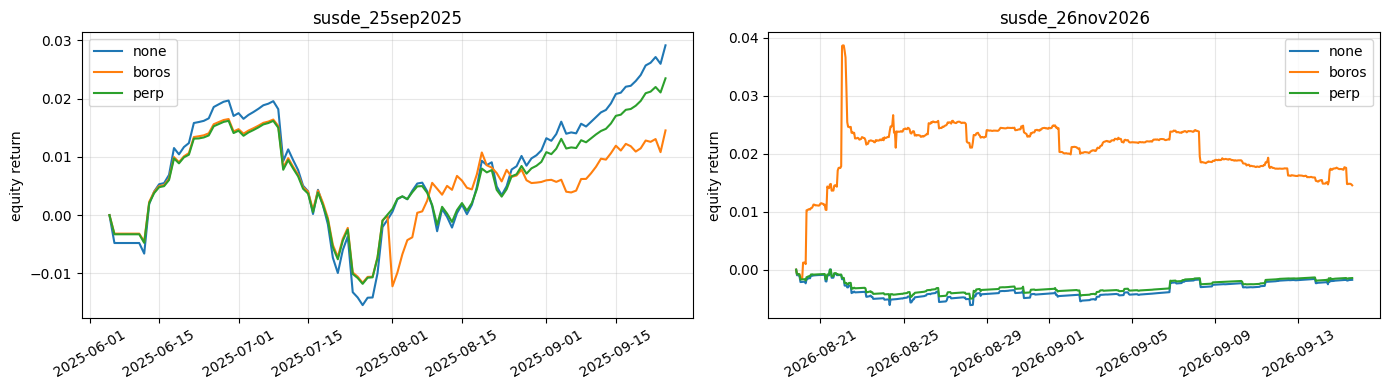

In [2]:
fig, axes = plt.subplots(1, len(markets), figsize=(7 * len(markets), 4), squeeze=False)
for ax, market in zip(axes[0], markets):
    for variant in variants:
        df = runs[f"{market}_{variant}"]
        ax.plot(df["timestamp"], df["net_balance"] / df["net_balance"].iloc[0] - 1, label=variant)
    ax.set_title(market); ax.set_ylabel("equity return"); ax.grid(alpha=0.3); ax.legend()
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

## 2. PnL decomposition per bar

`pt_carry` = PT units × Δprice (accretion to par and implied-APY marks), `interest` = debt × per-bar rate, `hedge` = Δ balance of the floating leg, `costs` = residual (swap fee + impact, hedge fees).

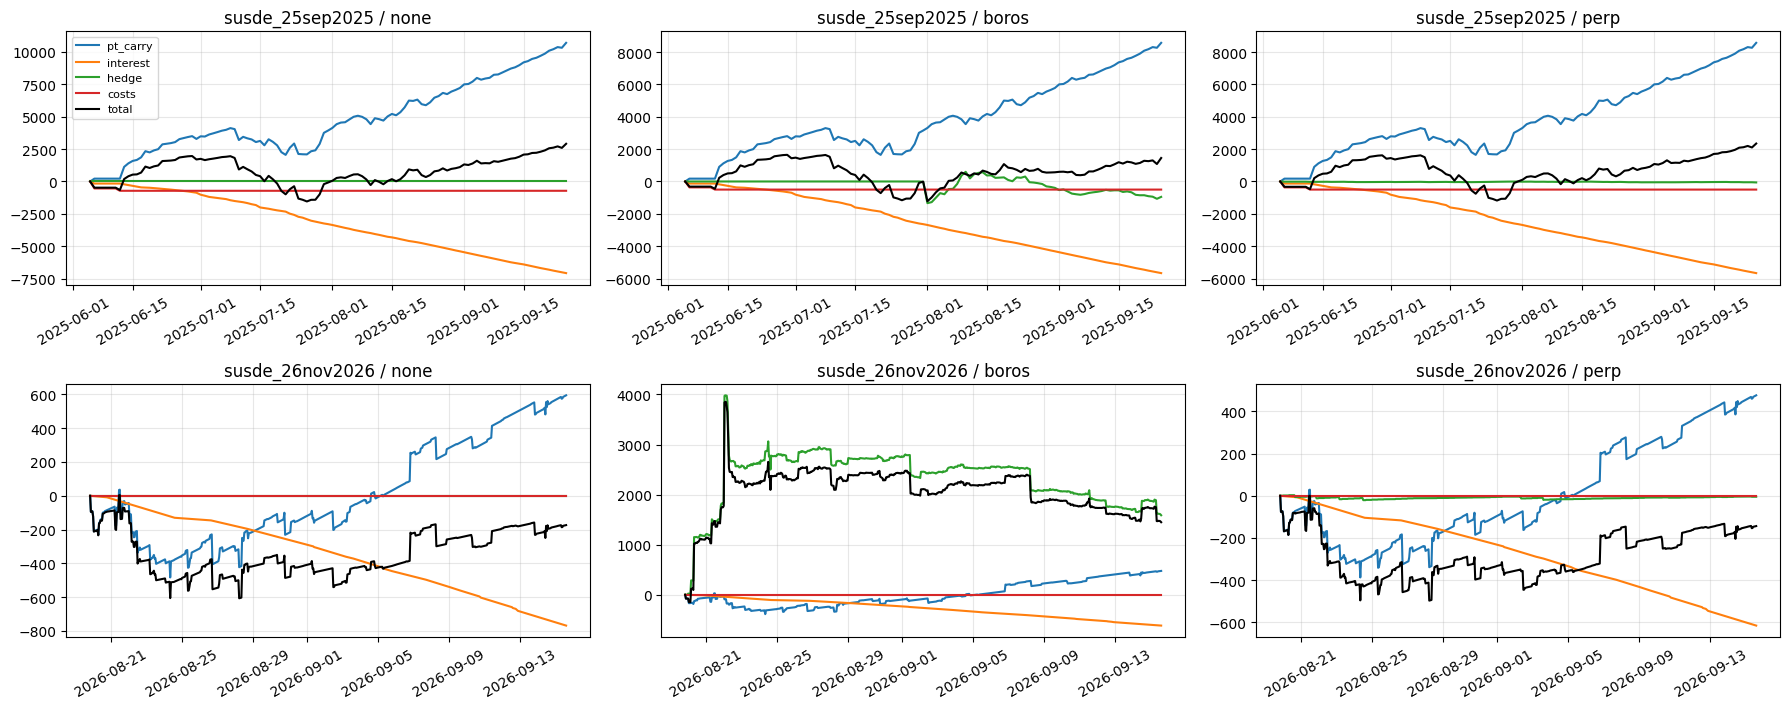

In [3]:
def decompose(df):
    price = (1.0 + df["PT_implied_apy"]) ** (-df["PT_seconds_to_expiry"] / YEAR)
    units = (df["PT_amount"] + df["LENDING_collateral"]).shift(1)
    out = pd.DataFrame(index=df["timestamp"])
    out["pt_carry"] = (units * price.diff()).values
    out["interest"] = -(df["LENDING_borrowed"].shift(1) * np.expm1(df["LENDING_borrowing_rate"])).values
    hedge = pd.Series(0.0, index=df.index)
    if "BOROS_balance" in df:
        hedge = df["BOROS_balance"].ffill().diff()
    elif "PERP_balance" in df:
        hedge = (df["SPOT_balance"] + df["PERP_balance"]).diff()
    out["hedge"] = hedge.values
    out["costs"] = (df["net_balance"].diff() - out["pt_carry"].values - out["interest"].values - out["hedge"].values).values
    out.iloc[0] = 0.0
    return out.fillna(0.0)

decomp = {name: decompose(df) for name, df in runs.items()}
fig, axes = plt.subplots(len(markets), len(variants), figsize=(6 * len(variants), 3.6 * len(markets)), squeeze=False)
for i, market in enumerate(markets):
    for j, variant in enumerate(variants):
        d = decomp[f"{market}_{variant}"].cumsum()
        ax = axes[i][j]
        for col in d.columns:
            ax.plot(d.index, d[col], label=col)
        ax.plot(d.index, d.sum(axis=1), color="black", lw=1.5, label="total")
        ax.set_title(f"{market} / {variant}"); ax.grid(alpha=0.3); ax.tick_params(axis="x", rotation=30)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
plt.tight_layout()

In [4]:
totals = pd.DataFrame({name: d.sum() for name, d in decomp.items()}).T
totals["equity_change"] = [runs[n]["net_balance"].iloc[-1] - runs[n]["net_balance"].iloc[0] for n in totals.index]
totals.round(1)

,pt_carry,interest,hedge,costs,equity_change
susde_25sep2025_boros,8568.9,-5663.7,-952.3,-501.0,1451.9
susde_25sep2025_none,10700.2,-7072.5,0.0,-718.7,2909.1
susde_25sep2025_perp,8568.9,-5663.7,-59.5,-501.0,2344.7
susde_26nov2026_boros,476.1,-615.1,1587.6,0.0,1448.5
susde_26nov2026_none,594.6,-768.2,0.0,0.0,-173.6
susde_26nov2026_perp,476.1,-615.1,-4.6,0.0,-143.6


## 3. APY and drawdown

In [5]:
cols = ["market", "variant", "bars", "leverage_at_entry", "pt_apy_at_entry", "borrow_apy_mean", "funding_apr_mean",
        "boros_mark_apr_mean", "realised_apy", "max_drawdown", "hedge_coverage_mean", "hedge_pnl", "min_health_factor",
        "liquidations"]
validation[cols].round(4)

,market,variant,bars,leverage_at_entry,pt_apy_at_entry,borrow_apy_mean,funding_apr_mean,boros_mark_apr_mean,realised_apy,max_drawdown,hedge_coverage_mean,hedge_pnl,min_health_factor,liquidations
0,susde_25sep2025,none,113,4.3301,0.0811,0.0793,0.0582,0.0664,0.0982,-0.0344,NaN,0.0000,1.1851,0
1,susde_25sep2025,boros,113,3.4628,0.0811,0.0793,0.0582,0.0664,0.0482,-0.0282,0.5238,-952.3194,1.1851,0
2,susde_25sep2025,perp,113,3.4632,0.0811,0.0793,0.0582,0.0664,0.0786,-0.0275,0.0496,-70.8546,1.1851,0
3,susde_26nov2026,none,643,4.3315,0.0407,0.0322,0.0557,0.0566,-0.0236,-0.0061,NaN,0.0000,1.1878,0
4,susde_26nov2026,boros,643,3.4632,0.0407,0.0322,0.0557,0.0566,0.2178,-0.0232,0.9907,1541.3703,1.1879,0
5,susde_26nov2026,perp,643,3.4619,0.0407,0.0322,0.0557,0.0566,-0.0195,-0.0050,0.0497,-15.9505,1.1879,0


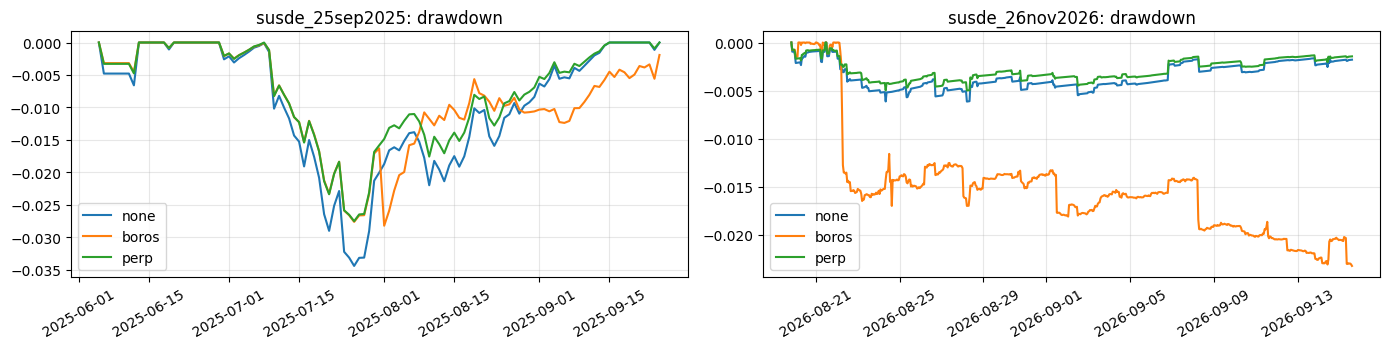

In [6]:
fig, axes = plt.subplots(1, len(markets), figsize=(7 * len(markets), 3.6), squeeze=False)
for ax, market in zip(axes[0], markets):
    for variant in variants:
        df = runs[f"{market}_{variant}"]
        ax.plot(df["timestamp"], df["net_balance"] / df["net_balance"].cummax() - 1, label=variant)
    ax.set_title(f"{market}: drawdown"); ax.grid(alpha=0.3); ax.legend(); ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

## 4. Costs

`entry_cost` = equity after the entry loops minus the 100k deposit (swap fee + impact); `costs_total` = residual of the decomposition after entry (re-lever / de-lever swaps, hedge fees); turnover = bars where the debt moved by more than 1 %.

In [7]:
rows = []
for name, d in decomp.items():
    df = runs[name]
    start_equity = df["net_balance"].iloc[0]
    years = (df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]).total_seconds() / YEAR
    initial = float(validation.loc[(validation["market"] + "_" + validation["variant"]) == name, "final_equity"].size
                    and 100_000.0)
    rows.append({
        "run": name,
        "entry_cost": df["net_balance"].iloc[0] - initial,  # swap fee + impact of the entry loops
        "costs_total": d["costs"].sum(),
        "costs_pct_of_equity": d["costs"].sum() / start_equity,
        "costs_apy_drag": d["costs"].sum() / start_equity / years,
        "interest_total": d["interest"].sum(),
        "pt_carry_total": d["pt_carry"].sum(),
        "hedge_total": d["hedge"].sum(),
        "debt_changes": int((df["LENDING_borrowed"].pct_change().abs() > 0.01).sum()),
    })
pd.DataFrame(rows).set_index("run").round(4)

,entry_cost,costs_total,costs_pct_of_equity,costs_apy_drag,interest_total,pt_carry_total,hedge_total,debt_changes
run,,,,,,,,
susde_25sep2025_boros,-144.3766,-501.0315,-0.0050,-0.0164,-5663.7208,8568.9384,-952.3194,3
susde_25sep2025_none,-192.4044,-718.6924,-0.0072,-0.0235,-7072.4539,10700.2294,0.0000,3
susde_25sep2025_perp,-155.7076,-501.0315,-0.0050,-0.0164,-5663.7208,8568.9384,-59.5236,3
susde_26nov2026_boros,-433.9943,0.0000,0.0000,0.0000,-615.1267,476.1041,1587.5685,0
susde_26nov2026_none,-586.8016,0.0000,0.0000,0.0000,-768.2050,594.5705,0.0000,0
susde_26nov2026_perp,-399.1272,0.0000,0.0000,0.0000,-615.1267,476.1041,-4.6195,0


## 5. Parameter grid

Realised APY by target LTV and hedge variant (`grid.py`: LTV × hedge × margin share × ratio).

target_ltv,0.60,0.70,0.80,0.86
cell,,,,
boros s=0.1 r=0.5,-0.0162,-0.0220,-0.0311,-0.0391
boros s=0.1 r=1.0,-0.0162,-0.0220,-0.0317,-0.0412
boros s=0.3 r=0.5,-0.0126,-0.0171,-0.0242,-0.0306
boros s=0.3 r=1.0,-0.0126,-0.0171,-0.0248,-0.0322
none,-0.0179,-0.0244,-0.0344,-0.0434
perp s=0.1 r=0.5,-0.0161,-0.0220,-0.0310,-0.0391
perp s=0.1 r=1.0,-0.0161,-0.0220,-0.0310,-0.0391
perp s=0.3 r=0.5,-0.0125,-0.0171,-0.0241,-0.0304
perp s=0.3 r=1.0,-0.0125,-0.0171,-0.0241,-0.0304


target_ltv,0.60,0.70,0.80,0.86
cell,,,,
boros s=0.1 r=0.5,-0.0056,-0.0086,-0.0136,-0.0179
boros s=0.1 r=1.0,-0.0110,-0.0169,-0.0260,-0.0337
boros s=0.3 r=0.5,-0.0044,-0.0067,-0.0106,-0.0139
boros s=0.3 r=1.0,-0.0086,-0.0133,-0.0204,-0.0265
none,-0.0034,-0.0045,-0.0061,-0.0076
perp s=0.1 r=0.5,-0.0031,-0.0040,-0.0056,-0.0069
perp s=0.1 r=1.0,-0.0031,-0.0040,-0.0056,-0.0069
perp s=0.3 r=0.5,-0.0025,-0.0032,-0.0044,-0.0055
perp s=0.3 r=1.0,-0.0025,-0.0032,-0.0044,-0.0055


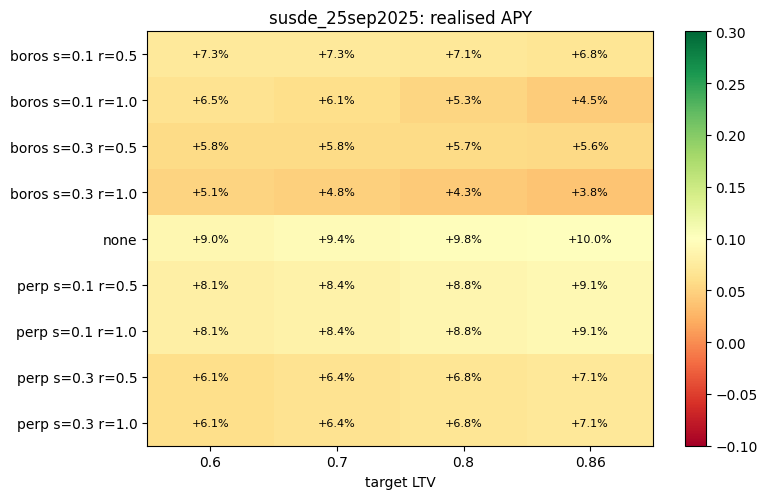

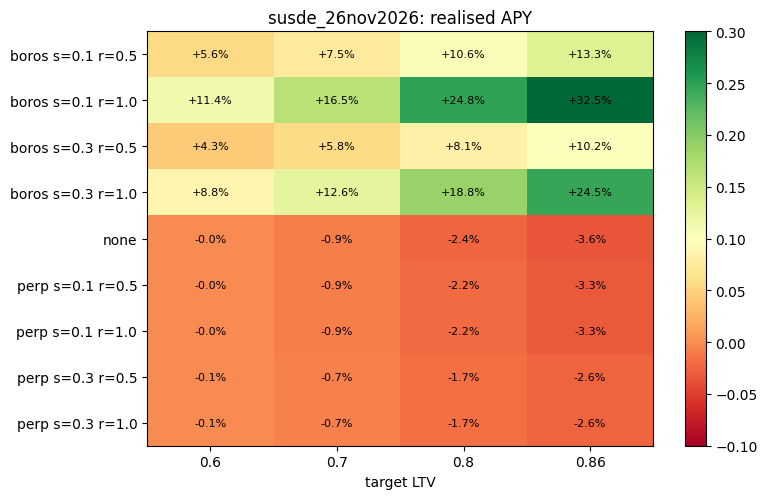

In [8]:
for market in markets:
    path = os.path.join(RESULTS, f"grid_{market}.csv")
    if not os.path.exists(path):
        continue
    g = pd.read_csv(path)
    g["cell"] = g.apply(lambda r: r["variant"] if r["variant"] == "none"
                        else f"{r['variant']} s={r['hedge_margin_share']} r={r['hedge_ratio']}", axis=1)
    table = g.pivot_table(index="cell", columns="target_ltv", values="realised_apy")
    fig, ax = plt.subplots(figsize=(8, 0.4 * len(table) + 1.5))
    im = ax.imshow(table.values, aspect="auto", cmap="RdYlGn", vmin=-0.1, vmax=0.3)
    ax.set_xticks(range(len(table.columns))); ax.set_xticklabels(table.columns)
    ax.set_yticks(range(len(table.index))); ax.set_yticklabels(table.index)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, f"{table.values[i, j]:+.1%}", ha="center", va="center", fontsize=8)
    ax.set_title(f"{market}: realised APY"); ax.set_xlabel("target LTV")
    plt.colorbar(im, ax=ax); plt.tight_layout()
    display(g.pivot_table(index="cell", columns="target_ltv", values="max_drawdown").round(4))

## 6. Hedge leg: coverage, settlements and mark-to-maturity

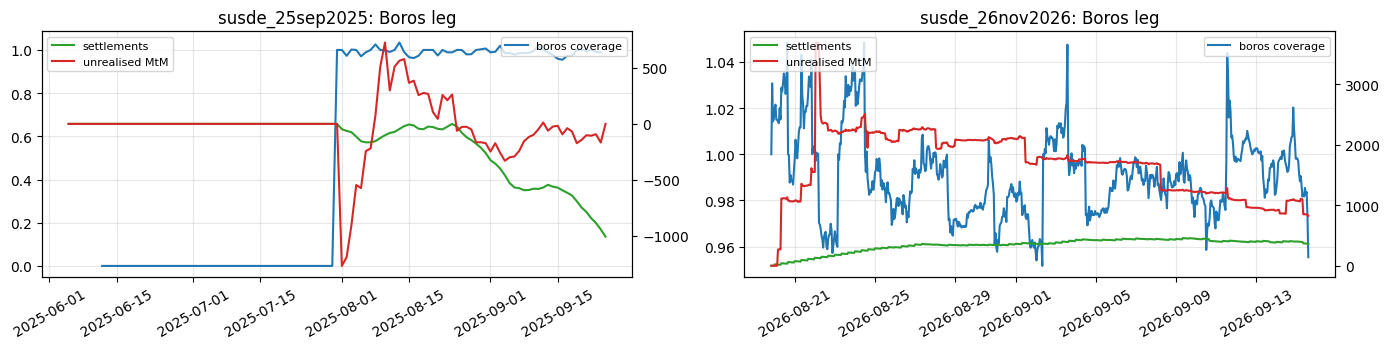

In [9]:
fig, axes = plt.subplots(1, len(markets), figsize=(7 * len(markets), 3.6), squeeze=False)
for ax, market in zip(axes[0], markets):
    df = runs[f"{market}_boros"]
    if "BOROS_size" in df:
        cov = (df["BOROS_size"].fillna(0) * df["BOROS_underlying_price"].fillna(0)
               / df["LENDING_borrowed"].replace(0, np.nan))
        ax.plot(df["timestamp"], cov, label="boros coverage")
        ax2 = ax.twinx()
        ax2.plot(df["timestamp"], df["BOROS_realized_settlements"].fillna(0), color="tab:green", label="settlements")
        ax2.plot(df["timestamp"], (df["BOROS_balance"].ffill() - df["BOROS_collateral"].ffill()).fillna(0),
                 color="tab:red", label="unrealised MtM")
        ax2.legend(loc="upper left", fontsize=8)
    ax.set_title(f"{market}: Boros leg"); ax.grid(alpha=0.3); ax.legend(loc="upper right", fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()